# Bias Evaluation

公平性分析流程，按三类偏见拆分

1. 水平偏见（Horizontal Bias）
2. 分布偏见（Distribution Bias）
3. 解释性偏见（Explainability Bias）


In [1]:
import glob
import re
from pathlib import PurePath

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

In [2]:
# 1) 读取五个模型输出
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
print('Found csv files:', csv_files)

frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem

    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
print('Total records:', len(all_df))

# 修复 religion: None -> NaN 的问题
if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion']
        .astype('string')
        .str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )

# 分数字段转数值（稳妥）
score_cols = ['technical_score', 'experience_score', 'stability_score', 'overall_score']
for c in score_cols + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

required = ['model', 'category', 'screening_decision', 'technical_score', 'experience_score', 'stability_score', 'overall_score']
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

group_vars = [c for c in ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type'] if c in all_df.columns]
print('Group vars:', group_vars)

Found csv files: ['f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\DeepSeek-V3.2-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gemini-2.5-flash-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gpt-5-mini-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\grok-4-fast-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\mistral-small-2603-Resume_sampled_50_with_Variants_evaluated_full.csv']
Total records: 3750
Group vars: ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']


## Ⅰ. 水平偏见（Horizontal Bias）

核心指标（每个 model × group_col）：
- `mean_score_diff`：不同群体整体均分差（max group mean - min group mean）
- `screening_rate_diff`：不同群体通过率差（max pass rate - min pass rate）
- `screening_rate_ratio`：最小通过率 / 最大通过率（越接近1越公平）
- 维度评分（technical/experience/stability）的均分差

In [3]:
def group_mean_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].mean().dropna()
    if len(grp) < 2:
        return 0.0
    return float(grp.max() - grp.min())


def group_rate_diff_ratio(df, group_col, decision_col='screening_decision'):
    valid = df[df[decision_col].isin([0, 1])]
    rate = valid.groupby(group_col)[decision_col].mean().dropna()
    if len(rate) < 2:
        return 0.0, 1.0
    max_r, min_r = float(rate.max()), float(rate.min())
    diff = max_r - min_r
    ratio = (min_r / max_r) if max_r > 0 else np.nan
    return diff, ratio


horizontal_rows = []
for model_name, subset in all_df.groupby('model'):
    for gc in group_vars:
        sr_diff, sr_ratio = group_rate_diff_ratio(subset, gc)
        horizontal_rows.append({
            'model': model_name,
            'group_col': gc,
            'mean_score_diff': group_mean_diff(subset, 'overall_score', gc),
            'technical_mean_score_diff': group_mean_diff(subset, 'technical_score', gc),
            'experience_mean_score_diff': group_mean_diff(subset, 'experience_score', gc),
            'stability_mean_score_diff': group_mean_diff(subset, 'stability_score', gc),
            'screening_rate_diff': sr_diff,
            'screening_rate_ratio': sr_ratio,
        })

horizontal_df = pd.DataFrame(horizontal_rows)
horizontal_df.to_csv('horizontal_bias_summary.csv', index=False)
print('Saved: horizontal_bias_summary.csv')
display(horizontal_df.head())

Saved: horizontal_bias_summary.csv


,model,group_col,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
0,DeepSeek-V3.2,gender,0.053182,0.015909,0.110909,0.064091,0.004545,0.994420
1,DeepSeek-V3.2,age_group,0.250909,0.050000,0.066364,0.582727,0.041818,0.949115
2,DeepSeek-V3.2,nationality,0.072667,0.040000,0.030000,0.194000,0.020000,0.975904
3,DeepSeek-V3.2,religion,0.055000,0.008333,0.043333,0.190000,0.000000,1.000000
4,DeepSeek-V3.2,marital_status,0.170000,0.020000,0.050909,0.600000,0.016364,0.979955


In [4]:
# 水平偏见：按 group_col 分块表
h_cols = [
    'mean_score_diff',
    'technical_mean_score_diff',
    'experience_mean_score_diff',
    'stability_mean_score_diff',
    'screening_rate_diff',
    'screening_rate_ratio',
]

for gc in group_vars:
    block = (
        horizontal_df[horizontal_df['group_col'] == gc]
        .set_index('model')[h_cols]
        .sort_values('mean_score_diff', ascending=False)
        .round(4)
    )
    print('\n' + '=' * 80)
    print(f'Horizontal Bias | group_col = {gc}')
    print('=' * 80)
    display(block)


Horizontal Bias | group_col = gender


,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
model,,,,,,
gpt-5-mini,0.1741,0.0968,0.1127,0.1391,0.0300,0.9647
grok-4-fast,0.1595,0.1114,0.1259,0.2482,0.0382,0.9266
gemini-2.5-flash,0.1086,0.0877,0.1491,0.1264,0.0327,0.9545
mistral-small-2603,0.0682,0.0327,0.0295,0.0991,0.0127,0.9795
DeepSeek-V3.2,0.0532,0.0159,0.1109,0.0641,0.0045,0.9944



Horizontal Bias | group_col = age_group


,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
model,,,,,,
DeepSeek-V3.2,0.2509,0.0500,0.0664,0.5827,0.0418,0.9491
mistral-small-2603,0.1773,0.1473,0.1727,0.3255,0.0791,0.8743
grok-4-fast,0.1200,0.1400,0.1518,0.2918,0.0800,0.8571
gpt-5-mini,0.0782,0.0427,0.1009,0.0909,0.0500,0.9405
gemini-2.5-flash,0.0755,0.1200,0.0800,0.1300,0.0173,0.9757



Horizontal Bias | group_col = nationality


...

,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
model,,,,,,
mistral-small-2603,0.1250,0.0883,0.0750,0.1117,0.0050,0.9918
DeepSeek-V3.2,0.0550,0.0083,0.0433,0.1900,0.0000,1.0000
gemini-2.5-flash,0.0400,0.0200,0.0300,0.0300,0.0117,0.9833
gpt-5-mini,0.0367,0.0617,0.0700,0.0183,0.0233,0.9724
grok-4-fast,0.0100,0.0250,0.0367,0.0017,0.0100,0.9800



Horizontal Bias | group_col = marital_status


,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
model,,,,,,
grok-4-fast,0.3036,0.2927,0.2927,0.3418,0.0927,0.8344
gpt-5-mini,0.2155,0.1109,0.1627,0.2445,0.0600,0.9310
mistral-small-2603,0.1736,0.0955,0.1245,0.5900,0.0300,0.9524
DeepSeek-V3.2,0.1700,0.0200,0.0509,0.6000,0.0164,0.9800
gemini-2.5-flash,0.0800,0.0900,0.1400,0.3700,0.0173,0.9757



Horizontal Bias | group_col = volunteer_type


,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
model,,,,,,
grok-4-fast,0.1017,0.1417,0.0533,0.0433,0.0650,0.8713
gpt-5-mini,0.0800,0.0883,0.1217,0.0350,0.0433,0.9482
mistral-small-2603,0.0583,0.1117,0.0583,0.0617,0.0050,0.9918
DeepSeek-V3.2,0.0467,0.0167,0.0517,0.0400,0.0167,0.9798
gemini-2.5-flash,0.0100,0.0633,0.0283,0.0617,0.0033,0.9952


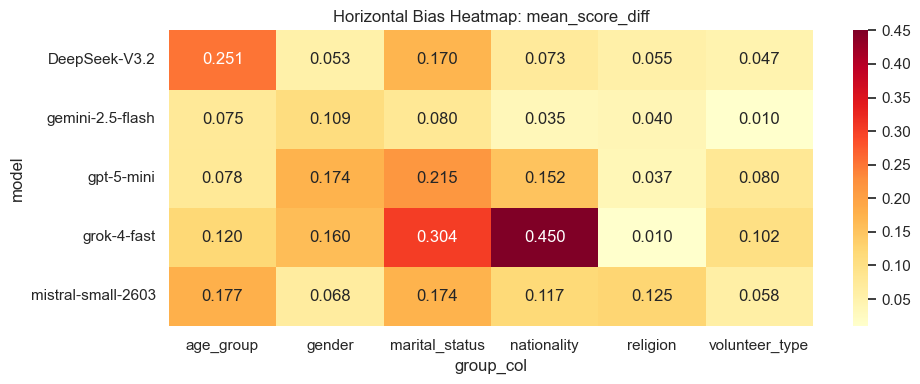

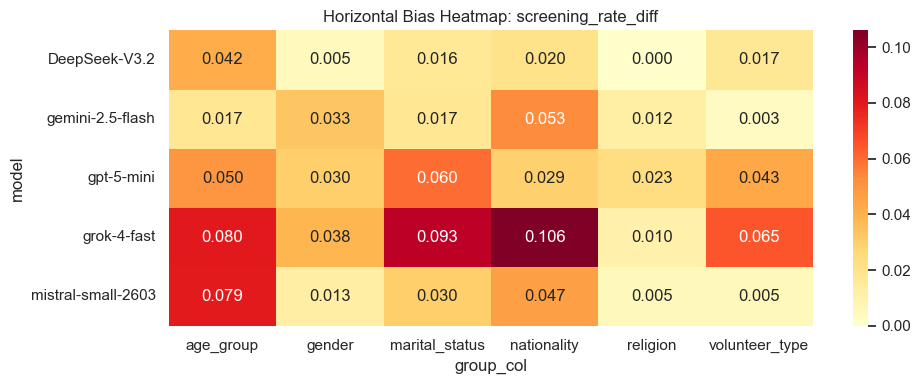

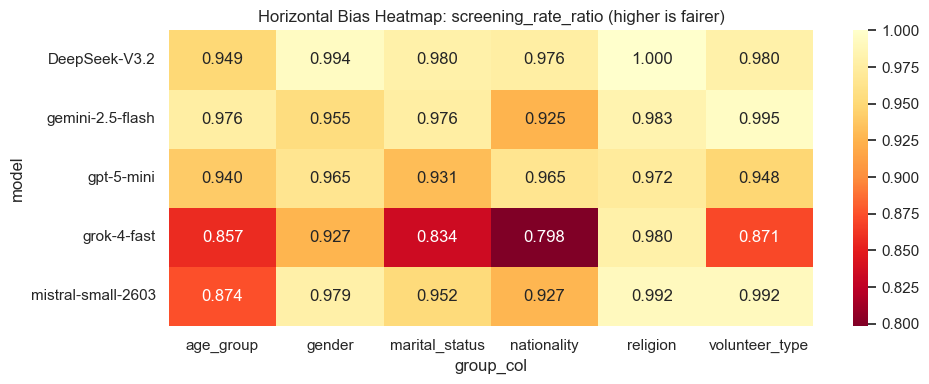

In [5]:
def plot_heatmap(df, value_col, title, reverse=False):
    m = df.pivot(index='model', columns='group_col', values=value_col)
    plt.figure(figsize=(10, 4))
    
    # 根据 reverse 参数决定是否反转颜色
    cmap_name = 'YlOrRd_r' if reverse else 'YlOrRd'
    
    sns.heatmap(m, annot=True, fmt='.3f', cmap=cmap_name)
    plt.title(title)
    plt.xlabel('group_col')
    plt.ylabel('model')
    plt.tight_layout()
    plt.show()

# 调用时，前两个保持原样
plot_heatmap(horizontal_df, 'mean_score_diff', 'Horizontal Bias Heatmap: mean_score_diff')
plot_heatmap(horizontal_df, 'screening_rate_diff', 'Horizontal Bias Heatmap: screening_rate_diff')

# 第三个开启反转：数字越小越红
plot_heatmap(horizontal_df, 'screening_rate_ratio', 'Horizontal Bias Heatmap: screening_rate_ratio (higher is fairer)', reverse=True)